<a href="https://colab.research.google.com/github/kudupudimeghana/GenAI-NLP/blob/main/6_dog_and_cat_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
print(os.listdir("../input"))

import zipfile

with zipfile.ZipFile("/kaggle/input/dogs-vs-cats/test1.zip","r") as z:
    z.extractall(".")

with zipfile.ZipFile("/kaggle/input/dogs-vs-cats/train.zip","r") as z:
    z.extractall(".")

['dogs-vs-cats']


!ls train

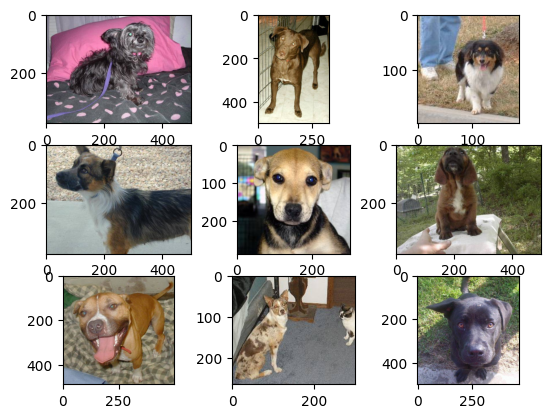

In [ ]:
# plot dog photos from the dogs vs cats dataset
from matplotlib import pyplot
from matplotlib.image import imread
# define location of dataset
folder = 'train/'
# plot first few images
for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# define filename
	filename = folder + 'dog.' + str(i) + '.jpg'
	# load image pixels
	image = imread(filename)
	# plot raw pixel data
	pyplot.imshow(image)
# show the figure
pyplot.show()

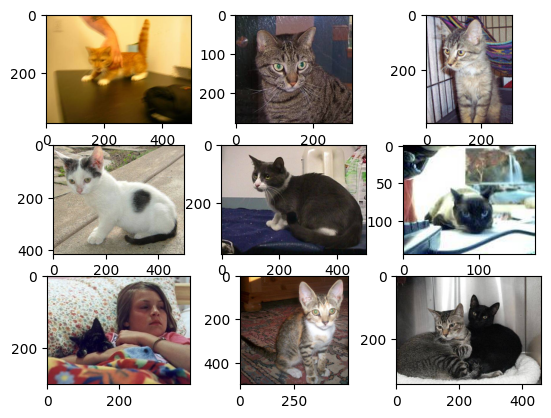

In [ ]:
# plot cat photos from the dogs vs cats dataset
from matplotlib import pyplot
from matplotlib.image import imread
# define location of dataset
folder = 'train/'
# plot first few images
for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# define filename
	filename = folder + 'cat.' + str(i) + '.jpg'
	# load image pixels
	image = imread(filename)
	# plot raw pixel data
	pyplot.imshow(image)
# show the figure
pyplot.show()

In [ ]:
# load dogs vs cats dataset, reshape and save to a new file
from os import listdir
from numpy import asarray
from numpy import save
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# define location of dataset
folder = 'train/'
photos, labels = list(), list()
# enumerate files in the directory
for file in listdir(folder):
	# determine class
	output = 0.0
	if file.startswith('dog'):
		output = 1.0
	# load image
	photo = load_img(folder + file, target_size=(200, 200))
	# convert to numpy array
	photo = img_to_array(photo)
	# store
	photos.append(photo)
	labels.append(output)
# convert to a numpy arrays
photos = asarray(photos)
labels = asarray(labels)
print(photos.shape, labels.shape)
# save the reshaped photos
save('dogs_vs_cats_photos.npy', photos)
save('dogs_vs_cats_labels.npy', labels)

# load and confirm the shape
from numpy import load
photos = load('dogs_vs_cats_photos.npy')
labels = load('dogs_vs_cats_labels.npy')

In [ ]:

# organize dataset into a useful structure
from os import makedirs
from os import listdir
from shutil import copyfile
from random import seed
from random import random

In [ ]:
# create directories
dataset_home = 'dataset_dogs_vs_cats/'
subdirs = ['train/', 'test/']
for subdir in subdirs:
	# create label subdirectories
	labeldirs = ['dogs/', 'cats/']
	for labldir in labeldirs:
		newdir = dataset_home + subdir + labldir
		makedirs(newdir, exist_ok=True)

In [ ]:
# seed random number generator
seed(1)
# define ratio of pictures to use for validation
val_ratio = 0.25
# copy training dataset images into subdirectories
src_directory = 'train/'
for file in listdir(src_directory):
	src = src_directory + '/' + file
	dst_dir = 'train/'
	if random() < val_ratio:
		dst_dir = 'test/'
	if file.startswith('cat'):
		dst = dataset_home + dst_dir + 'cats/'  + file
		copyfile(src, dst)
	elif file.startswith('dog'):
		dst = dataset_home + dst_dir + 'dogs/'  + file
		copyfile(src, dst)

In [ ]:
!ls -l dataset_dogs_vs_cats/train/dogs | wc -l

9388


In [ ]:
!ls -l dataset_dogs_vs_cats/train/cats | wc -l

9311


In [ ]:
!pip -q install livelossplot==0.5.5

In [ ]:
from livelossplot import PlotLossesKeras

Prepare Final Dataset

In [ ]:
# save the final model to file
from keras.applications.vgg16 import VGG16
from keras.applications.xception import Xception
from keras.models import Model
from keras.layers import Dense
from keras.layers import Flatten
from keras.optimizers import SGD
from keras.preprocessing.image import ImageDataGenerator

xcep_model = Xception(include_top=False, input_shape=(299, 299, 3))
xcep_model.summary()

Data Augmentation

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
# create data generator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# prepare iterator
train_it = datagen.flow_from_directory('dataset_dogs_vs_cats/train/',
    class_mode='binary', batch_size=64, target_size=(224, 224))
test_it = datagen.flow_from_directory('dataset_dogs_vs_cats/test/',
    class_mode='binary', batch_size=64, target_size=(224, 224))

Found 18697 images belonging to 2 classes.
Found 6303 images belonging to 2 classes.


In [ ]:
# load model
model = VGG16(
    include_top=False,
    input_shape=(224, 224, 3)
    )
print(model.summary())
#model = Xception(include_top=False, input_shape=(299, 299, 3))

58889256/58889256 [==============================] - 3s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                              

In [ ]:
# mark loaded layers as not trainable
for index, layer in enumerate(model.layers[:15]):
    print(index, layer.name, layer.output_shape)
    layer.trainable = False #จะไม่ถูกอัปเดตค่าพารามิเตอร์ระหว่างการฝึก

for index, layer in enumerate(model.layers[15:]):
    print(index, layer.name, layer.output_shape)
    layer.trainable = True

0 input_1 [(None, 224, 224, 3)]
1 block1_conv1 (None, 224, 224, 64)
2 block1_conv2 (None, 224, 224, 64)
3 block1_pool (None, 112, 112, 64)
4 block2_conv1 (None, 112, 112, 128)
5 block2_conv2 (None, 112, 112, 128)
6 block2_pool (None, 56, 56, 128)
7 block3_conv1 (None, 56, 56, 256)
8 block3_conv2 (None, 56, 56, 256)
9 block3_conv3 (None, 56, 56, 256)
10 block3_pool (None, 28, 28, 256)
11 block4_conv1 (None, 28, 28, 512)
12 block4_conv2 (None, 28, 28, 512)
13 block4_conv3 (None, 28, 28, 512)
14 block4_pool (None, 14, 14, 512)
0 block5_conv1 (None, 14, 14, 512)
1 block5_conv2 (None, 14, 14, 512)
2 block5_conv3 (None, 14, 14, 512)
3 block5_pool (None, 7, 7, 512)


In [ ]:
model.layers[-1].output

<KerasTensor: shape=(None, 7, 7, 512) dtype=float32 (created by layer 'block5_pool')>

In [ ]:
flat1 = Flatten()(model.layers[-1].output) # เอา Output ของเลเยอร์สุดท้ายมาใช้
#นำมาต่อยอด
class1 = Dense(128, activation='relu', kernel_initializer='he_uniform')(flat1)
output = Dense(1, activation='sigmoid')(class1)
# define new model
my_model = Model(inputs=model.inputs, outputs=output)
# compile model
opt = SGD(lr=0.0001, momentum=0.9)
my_model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
my_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [ ]:
import matplotlib.pyplot as plt

def summarize_diagnostics(history):
    # วาดกราฟ Loss
    plt.subplot(211)
    plt.title('Cross Entropy Loss')
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='validation')
    plt.legend()

    # วาดกราฟ Accuracy
    plt.subplot(212)
    plt.title('Classification Accuracy')
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='validation')
    plt.legend()

    # แสดงกราฟ
    plt.tight_layout()
    plt.show()


In [ ]:
from keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=1e-7)

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

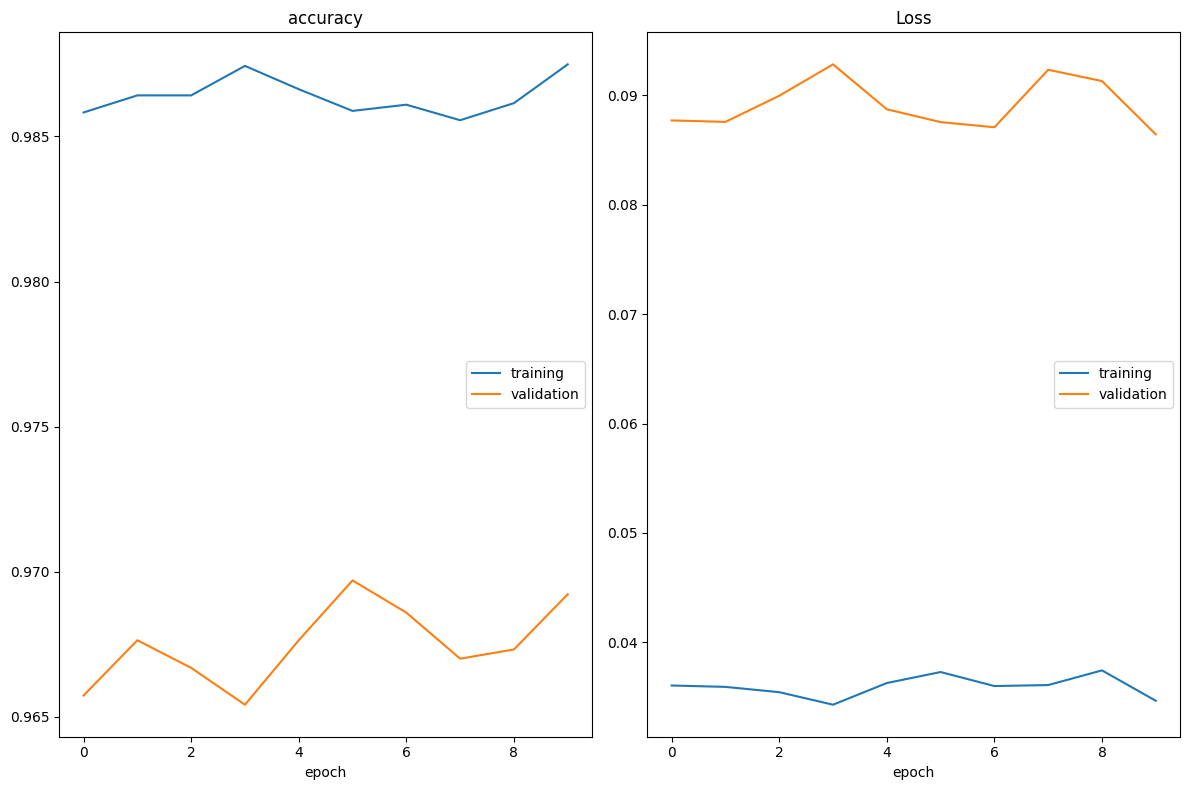

accuracy
	training         	 (min:    0.986, max:    0.987, cur:    0.987)
	validation       	 (min:    0.965, max:    0.970, cur:    0.969)
Loss
	training         	 (min:    0.034, max:    0.037, cur:    0.035)
	validation       	 (min:    0.086, max:    0.093, cur:    0.086)
99/99 [==============================] - 73s 737ms/step - loss: 0.0912 - accuracy: 0.9672
> 96.716


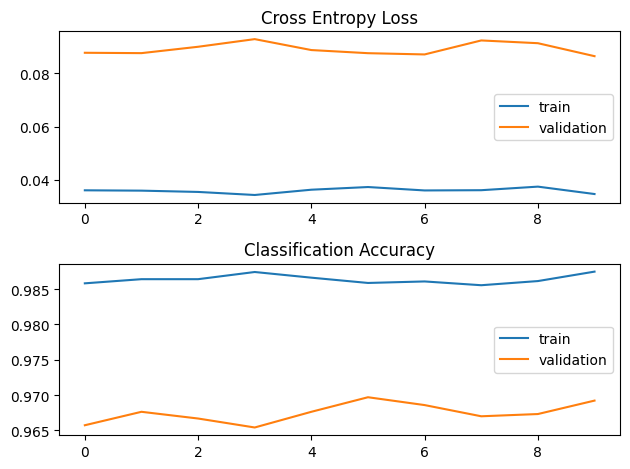

In [ ]:
 # fit model
my_model.reset_states()
history = my_model.fit(train_it,
                       validation_data=test_it,
                       epochs=10,
                       callbacks=[PlotLossesKeras(), lr_scheduler, early_stopping])
# evaluate model
_, acc = my_model.evaluate(test_it, steps=len(test_it), verbose=1)
print('> %.3f' % (acc * 100.0))
# learning curves
summarize_diagnostics(history)

best_model = 'vgg16_model.hdf5'
my_model.save(best_model)

## สุ่มรูป

In [ ]:
import os
import random
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
print(os.listdir('.'))

['train', '.virtual_documents', 'test1', 'dataset_dogs_vs_cats', 'vgg16_model.hdf5']


In [ ]:
#แก้ไฟล์ไม่มี label

# ระบุโฟลเดอร์
test_folder = 'test1'

# อ่านไฟล์ทั้งหมดใน test1
test_files = os.listdir(test_folder)

# สุ่ม 10 ไฟล์
random_files = random.sample(test_files, min(10, len(test_files)))

# แสดงผลรูปภาพ
for i, file in enumerate(random_files):
    pyplot.subplot(2, 5, 1 + i)  # 2 แถว 5 คอลัมน์
    image = imread(os.path.join(test_folder, file))
    pyplot.imshow(image)
    pyplot.axis('off')
    pyplot.title(file)  # แสดงชื่อไฟล์
pyplot.show()

NameError: name 'os' is not defined

In [ ]:
test_folder = './test1'

In [ ]:
test_dogs_dir = 'dataset_dogs_vs_cats/test/dogs/'
test_cats_dir = 'dataset_dogs_vs_cats/test/cats/'

In [ ]:
# สุ่ม 5 รูปจากแต่ละคลาส
dog_files = os.listdir(test_dogs_dir)
cat_files = os.listdir(test_cats_dir)

dog_samples = random.sample(dog_files, min(5, len(dog_files)))
cat_samples = random.sample(cat_files, min(5, len(cat_files)))

In [ ]:
sample_files = [(test_dogs_dir, f) for f in dog_samples] + [(test_cats_dir, f) for f in cat_samples]
random.shuffle(sample_files)  # สุ่มลำดับใหม่

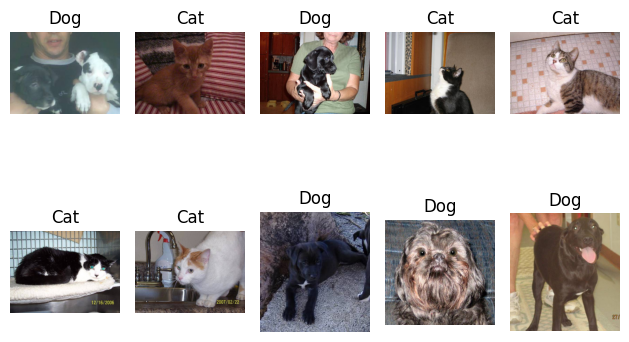

In [ ]:
for i, (folder, file) in enumerate(sample_files):
    pyplot.subplot(2, 5, 1 + i)  # 2 แถว 5 คอลัมน์
    image = imread(os.path.join(folder, file))
    pyplot.imshow(image)
    pyplot.axis('off')
    pyplot.title('Dog' if folder.endswith('dogs/') else 'Cat')
pyplot.tight_layout()
pyplot.show()

## predictions

In [ ]:
from keras.models import load_model

In [ ]:
# โหลดโมเดล
model = load_model('vgg16_model.hdf5')

In [ ]:
sample_files = [(test_dogs_dir, f, 'Dog') for f in dog_samples] + [(test_cats_dir, f, 'Cat') for f in cat_samples]
random.shuffle(sample_files)  # สุ่มลำดับใหม่

In [ ]:
# ฟังก์ชันสำหรับ Predict
def predict_image(file_path):
    img = load_img(file_path, target_size=(224, 224))  # โหลดและปรับขนาดภาพ
    img_array = img_to_array(img)  # แปลงเป็น numpy array
    img_array = img_array / 255.0  # rescale
    img_array = np.expand_dims(img_array, axis=0)  # เพิ่ม batch dimension
    prediction = model.predict(img_array)
    return 'Dog' if prediction[0][0] > 0.5 else 'Cat'

1/1 [==============================] - 0s 18ms/step


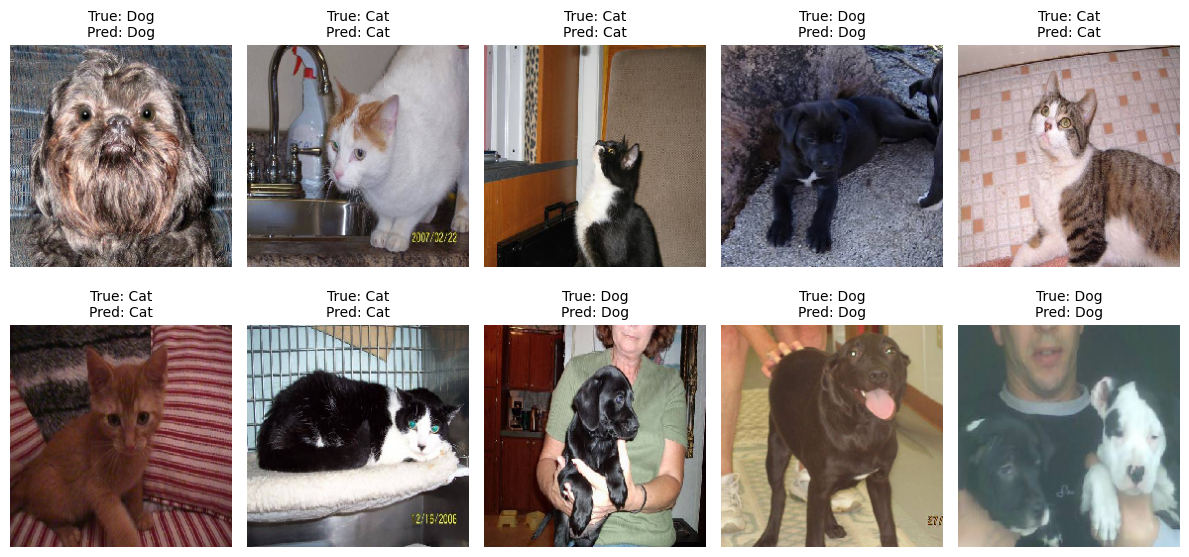

In [ ]:
# แสดงผล
plt.figure(figsize=(12, 6))  # กำหนดขนาดของรูป
for i, (folder, file, true_label) in enumerate(sample_files):
    file_path = os.path.join(folder, file)
    predicted_label = predict_image(file_path)  # ทำนายผลด้วยโมเดล

    # แสดงรูปภาพ
    plt.subplot(2, 5, i + 1)  # 2 แถว 5 คอลัมน์
    img = load_img(file_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)

plt.tight_layout()
plt.show()